# Airline Merger Damages Estimator — Exploratory Data Analysis

**STAT 418 — Data/ML/AI Applications, UCLA**  
**American Airlines / US Airways Merger (December 2013)**

Explores DOT DB1B Origin & Destination Survey data and FRED macroeconomic controls to characterize route-level fare patterns before and after the AA/US merger.

**Core question:** Did the merger cause ticket prices to rise on routes where AA and US previously competed directly?

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Paths (relative to notebooks/ directory)
DATA_DIR = Path('../data/raw/db1b')
FRED_DIR = Path('../data/raw/fred')
FIG_DIR  = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TREATED_COLOR = '#e74c3c'
CONTROL_COLOR = '#3498db'
MERGER_LABEL  = 'Merger (Q4 2013)'

def quarter_to_idx(year, q):
    """Maps (year, quarter) -> integer index where 2010 Q1 = 0, 2017 Q4 = 31."""
    return (year - 2010) * 4 + (q - 1)

print('Setup complete.')

Setup complete.


---
## Section 1 — Data Overview

Row counts per quarter, column schema, and missing values.

In [2]:
# Row counts for all 32 quarters — loads only one column per file
row_counts = {}
for year in range(2010, 2018):
    for q in range(1, 5):
        fp = DATA_DIR / f'db1b_market_{year}_Q{q}.parquet'
        row_counts[(year, q)] = pd.read_parquet(fp, columns=['Year']).shape[0]

print(f'Quarters loaded  : {len(row_counts)}')
print(f'Min rows/quarter : {min(row_counts.values()):,}')
print(f'Max rows/quarter : {max(row_counts.values()):,}')

Quarters loaded  : 32
Min rows/quarter : 4,906,864
Max rows/quarter : 6,860,743


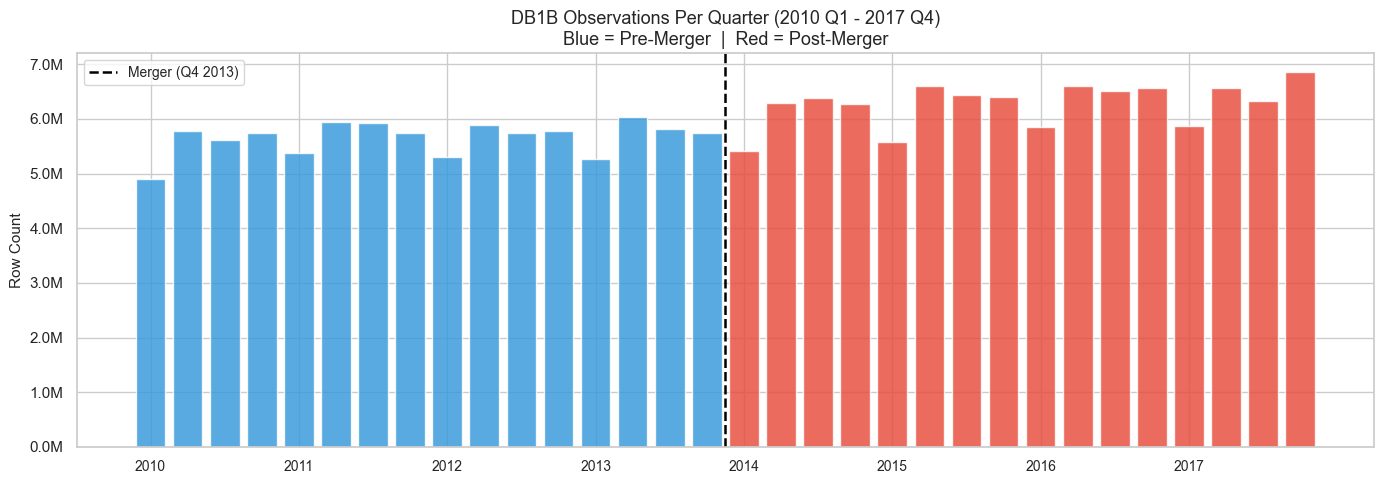

In [3]:
# Bar chart of row counts
sorted_keys = sorted(row_counts.keys())
x      = list(range(len(sorted_keys)))
values = [row_counts[k] for k in sorted_keys]
merger_x = quarter_to_idx(2013, 4)

fig, ax = plt.subplots(figsize=(14, 5))
colors = [TREATED_COLOR if i > merger_x else CONTROL_COLOR for i in x]
ax.bar(x, values, color=colors, alpha=0.82, edgecolor='white')
ax.axvline(merger_x + 0.5, color='black', linestyle='--', linewidth=1.8, label=MERGER_LABEL)

tick_pos  = [quarter_to_idx(y, 1) for y in range(2010, 2018)]
tick_labs = [str(y) for y in range(2010, 2018)]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labs, fontsize=10)
ax.set_title('DB1B Observations Per Quarter (2010 Q1 - 2017 Q4)\nBlue = Pre-Merger  |  Red = Post-Merger', fontsize=13)
ax.set_ylabel('Row Count', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'row_counts_per_quarter.png', dpi=150)
plt.show()

In [4]:
# Column summary from a representative quarter
df_schema = pd.read_parquet(DATA_DIR / 'db1b_market_2013_Q1.parquet')
if 'Unnamed: 41' in df_schema.columns:
    df_schema = df_schema.drop(columns=['Unnamed: 41'])

schema_tbl = pd.DataFrame({
    'dtype':        df_schema.dtypes.astype(str),
    'non_null_pct': (df_schema.notna().mean() * 100).round(1),
    'sample_value': [str(df_schema[c].dropna().iloc[0]) if df_schema[c].notna().any() else 'NaN'
                     for c in df_schema.columns]
})
schema_tbl.index.name = 'column'
display(schema_tbl)

,dtype,non_null_pct,sample_value
column,,,
ItinID,int64,100.0,20131625249
MktID,int64,100.0,2013162524901
MktCoupons,int64,100.0,1
Year,int64,100.0,2013
Quarter,int64,100.0,1
OriginAirportID,int64,100.0,15016
OriginAirportSeqID,int64,100.0,1501603
OriginCityMarketID,int64,100.0,31123
Origin,str,100.0,STL


In [5]:
# Missing values summary
missing = df_schema.isna().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print('No missing values in the substantive columns (Unnamed: 41 already dropped).')
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing.plot(kind='barh', ax=ax, color=TREATED_COLOR)
    ax.set_title('Columns with Missing Values (2013 Q1)', fontsize=12)
    ax.set_xlabel('% Missing')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'missing_values.png', dpi=150)
    plt.show()

del df_schema

No missing values in the substantive columns (Unnamed: 41 already dropped).


---
## Section 2 — Treatment vs Control Route Classification

**Treated routes:** Both AA and US operated on the route in ANY pre-merger quarter (2010–2013).  
**Control routes:** Only ONE of AA or US operated — used as the DiD counterfactual.  
Treatment is **route-level and time-invariant**.

In [6]:
# Determine treatment from all 16 pre-merger quarters
# Load only carrier + filter columns to save memory
aa_routes_pre = set()
us_routes_pre = set()

for year in range(2010, 2014):
    for q in range(1, 5):
        fp = DATA_DIR / f'db1b_market_{year}_Q{q}.parquet'
        df_tmp = pd.read_parquet(fp, columns=['Origin', 'Dest', 'OpCarrier',
                                               'MktGeoType', 'BulkFare', 'MktCoupons'])
        df_tmp = df_tmp[
            (df_tmp['BulkFare'] == 0) &
            (df_tmp['MktCoupons'] == 1) &
            (df_tmp['MktGeoType'].isin([1, 2])) &
            (df_tmp['OpCarrier'].isin(['AA', 'US']))
        ].copy()
        df_tmp['route'] = df_tmp['Origin'] + '-' + df_tmp['Dest']
        aa_routes_pre.update(df_tmp.loc[df_tmp['OpCarrier'] == 'AA', 'route'].unique())
        us_routes_pre.update(df_tmp.loc[df_tmp['OpCarrier'] == 'US', 'route'].unique())
        del df_tmp
        print(f'  Scanned {year} Q{q}', end='\r')

treated_routes = aa_routes_pre & us_routes_pre
control_routes = (aa_routes_pre | us_routes_pre) - treated_routes

print(f'\nTreated routes (AA + US overlap) : {len(treated_routes):,}')
print(f'Control routes (one carrier only) : {len(control_routes):,}')
print(f'Treatment share                   : {len(treated_routes)/(len(treated_routes)+len(control_routes)):.1%}')

  Scanned 2013 Q4
Treated routes (AA + US overlap) : 1,223
Control routes (one carrier only) : 3,723
Treatment share                   : 24.7%


In [7]:
# Load 4 representative quarters for detailed analysis
# 2011 Q1, 2012 Q1 = pre-merger  |  2014 Q1, 2015 Q1 = post-merger
SAMPLE_QUARTERS = [(2011, 1), (2012, 1), (2014, 1), (2015, 1)]

def load_and_clean(year, q):
    fp = DATA_DIR / f'db1b_market_{year}_Q{q}.parquet'
    cols = ['Origin', 'Dest', 'OpCarrier', 'TkCarrier', 'MktFare', 'Passengers',
            'MktDistance', 'MktMilesFlown', 'MktCoupons', 'BulkFare',
            'MktGeoType', 'OriginState', 'DestState', 'Year', 'Quarter']
    df = pd.read_parquet(fp, columns=cols)
    df = df[
        (df['BulkFare'] == 0) &
        (df['MktCoupons'] == 1) &
        (df['MktGeoType'].isin([1, 2])) &
        (df['MktFare'] > 20) &
        (df['MktFare'] < 2000)
    ].copy()
    df['route']      = df['Origin'] + '-' + df['Dest']
    df['Passengers'] = df['Passengers'] * 10   # DB1B is 10% sample
    return df

sample_dfs = []
for year, q in SAMPLE_QUARTERS:
    df_q = load_and_clean(year, q)
    sample_dfs.append(df_q)
    print(f'  Loaded {year} Q{q}: {len(df_q):,} rows')

sample_df = pd.concat(sample_dfs, ignore_index=True)
sample_df['treated'] = sample_df['route'].isin(treated_routes)
sample_df['period']  = sample_df['Year'].apply(lambda y: 'Pre-Merger' if y < 2014 else 'Post-Merger')
print(f'\nCombined sample: {len(sample_df):,} rows')

  Loaded 2011 Q1: 2,368,116 rows
  Loaded 2012 Q1: 2,241,815 rows
  Loaded 2014 Q1: 2,355,416 rows
  Loaded 2015 Q1: 2,511,782 rows

Combined sample: 9,477,129 rows


In [8]:
# Summary table: treated vs control (pre-merger sample)
pre = sample_df[sample_df['period'] == 'Pre-Merger']

def route_summary(df):
    return pd.Series({
        'N unique routes':           f"{df['route'].nunique():,}",
        'N passengers (scaled, M)':  f"{df['Passengers'].sum() / 1e6:.2f}",
        'Mean fare ($)':             f"{df['MktFare'].mean():.2f}",
        'Median fare ($)':           f"{df['MktFare'].median():.2f}",
        'Mean distance (mi)':        f"{df['MktDistance'].mean():.1f}",
    })

summary_tbl = pd.DataFrame({
    'Treated Routes': route_summary(pre[pre['treated']]),
    'Control Routes': route_summary(pre[~pre['treated']]),
    'All Routes':     route_summary(pre),
})
display(summary_tbl)

,Treated Routes,Control Routes,All Routes
N unique routes,"1,207","8,311","9,518"
"N passengers (scaled, M)",54.51,70.91,125.42
Mean fare ($),263.10,218.36,237.87
Median fare ($),204.00,178.50,189.43
Mean distance (mi),1227.6,818.8,997.1


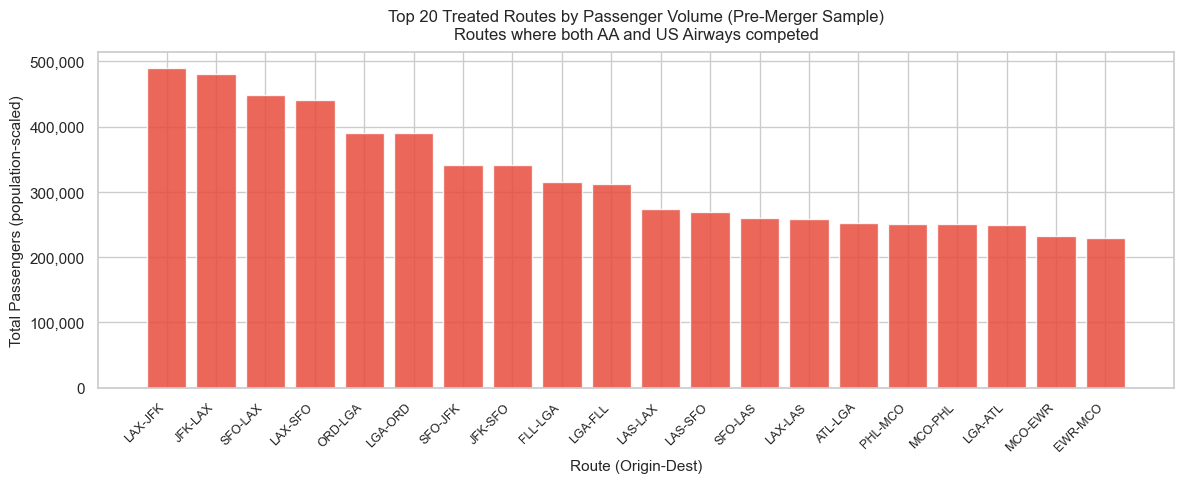

In [9]:
# Top 20 treated routes by passenger volume
pre_treated = sample_df[(sample_df['period'] == 'Pre-Merger') & sample_df['treated']]
top_treated = (
    pre_treated.groupby('route')
    .agg(total_pax=('Passengers', 'sum'), avg_fare=('MktFare', 'mean'))
    .sort_values('total_pax', ascending=False).head(20).reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_treated['route'], top_treated['total_pax'],
       color=TREATED_COLOR, alpha=0.85, edgecolor='white')
ax.set_title('Top 20 Treated Routes by Passenger Volume (Pre-Merger Sample)\n'
             'Routes where both AA and US Airways competed', fontsize=12, pad=10)
ax.set_xlabel('Route (Origin-Dest)', fontsize=11)
ax.set_ylabel('Total Passengers (population-scaled)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_treated_routes.png', dpi=150)
plt.show()

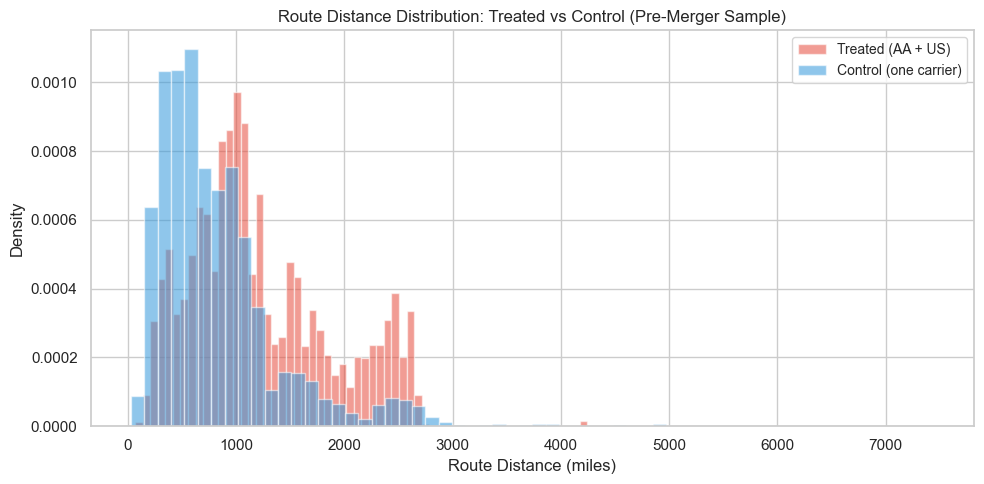

In [10]:
# Route distance distribution: treated vs control
pre = sample_df[sample_df['period'] == 'Pre-Merger']

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, mask in [
    ('Treated (AA + US)', TREATED_COLOR, pre['treated']),
    ('Control (one carrier)', CONTROL_COLOR, ~pre['treated'])
]:
    ax.hist(pre.loc[mask, 'MktDistance'].dropna(), bins=60,
            alpha=0.55, color=color, density=True, label=label)

ax.set_title('Route Distance Distribution: Treated vs Control (Pre-Merger Sample)', fontsize=12)
ax.set_xlabel('Route Distance (miles)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'distance_distribution.png', dpi=150)
plt.show()

---
## Section 3 — Fare Analysis

The **pre-trends chart** below is the most important plot in the EDA. Parallel pre-merger trends between treated and control routes is the key identifying assumption for DiD.

In [11]:
# Build quarterly fare averages for treated vs control (all 32 quarters)
quarterly_stats = []

for year in range(2010, 2018):
    for q in range(1, 5):
        fp = DATA_DIR / f'db1b_market_{year}_Q{q}.parquet'
        cols = ['Origin', 'Dest', 'OpCarrier', 'MktFare', 'Passengers',
                'MktGeoType', 'BulkFare', 'MktCoupons']
        df_tmp = pd.read_parquet(fp, columns=cols)
        df_tmp = df_tmp[
            (df_tmp['BulkFare'] == 0) &
            (df_tmp['MktCoupons'] == 1) &
            (df_tmp['MktGeoType'].isin([1, 2])) &
            (df_tmp['MktFare'] > 20) &
            (df_tmp['MktFare'] < 2000) &
            (df_tmp['OpCarrier'].isin(['AA', 'US']))
        ].copy()
        df_tmp['route'] = df_tmp['Origin'] + '-' + df_tmp['Dest']
        df_tmp['Passengers_scaled'] = df_tmp['Passengers'] * 10

        is_treated = df_tmp['route'].isin(treated_routes)
        for treated_flag, grp in [(True, 'Treated'), (False, 'Control')]:
            subset = df_tmp[is_treated if treated_flag else ~is_treated]
            if len(subset) > 0:
                quarterly_stats.append({
                    'year': year, 'quarter': q,
                    'quarter_idx': quarter_to_idx(year, q),
                    'group':             grp,
                    'avg_fare':          subset['MktFare'].mean(),
                    'median_fare':       subset['MktFare'].median(),
                    'total_passengers':  subset['Passengers_scaled'].sum(),
                    'n_routes':          subset['route'].nunique(),
                })
        del df_tmp
        print(f'  Processed {year} Q{q}', end='\r')

ts_df = pd.DataFrame(quarterly_stats).sort_values(['quarter_idx', 'group'])
print(f'\nTime series built: {len(ts_df)} rows')

  Processed 2017 Q4
Time series built: 64 rows


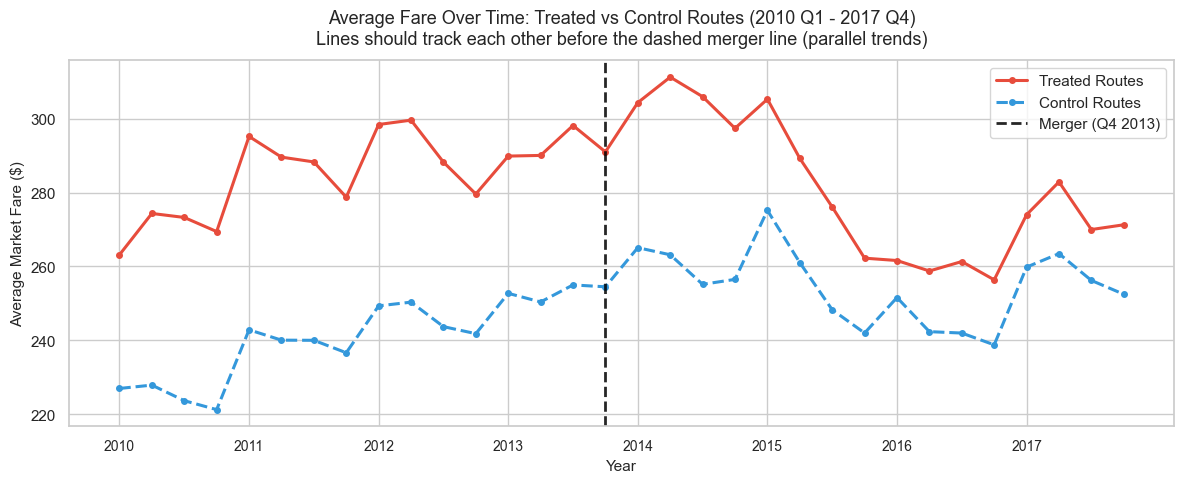

In [12]:
# *** KEY PLOT: Average quarterly fare — treated vs control (pre-trends check) ***
merger_qidx = quarter_to_idx(2013, 4)

fig, ax = plt.subplots(figsize=(12, 5))
for grp, color, ls in [('Treated', TREATED_COLOR, '-'), ('Control', CONTROL_COLOR, '--')]:
    sub = ts_df[ts_df['group'] == grp].sort_values('quarter_idx')
    ax.plot(sub['quarter_idx'], sub['avg_fare'],
            color=color, linestyle=ls, linewidth=2.2, marker='o',
            markersize=4, label=f'{grp} Routes')

ax.axvline(merger_qidx, color='black', linestyle='--', linewidth=2,
           label=MERGER_LABEL, alpha=0.85)

tick_pos  = [quarter_to_idx(y, 1) for y in range(2010, 2018)]
ax.set_xticks(tick_pos)
ax.set_xticklabels([str(y) for y in range(2010, 2018)], fontsize=10)
ax.set_title('Average Fare Over Time: Treated vs Control Routes (2010 Q1 - 2017 Q4)\n'
             'Lines should track each other before the dashed merger line (parallel trends)',
             fontsize=13, pad=12)
ax.set_ylabel('Average Market Fare ($)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fare_trends_treated_vs_control.png', dpi=150)
plt.show()

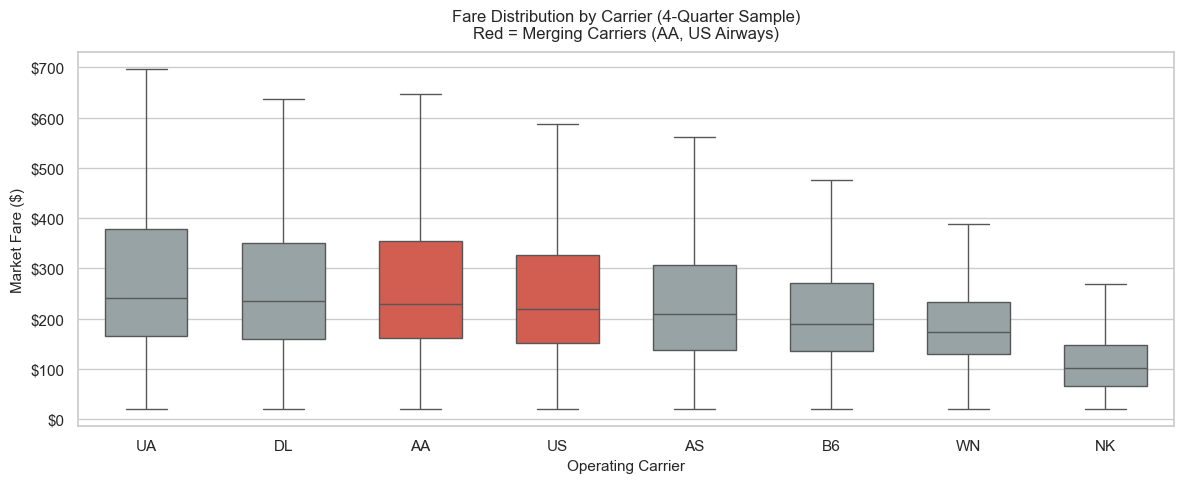

In [13]:
# Fare distribution by carrier — box plots (4-quarter sample)
top_carriers = (
    sample_df.groupby('OpCarrier')['Passengers'].sum()
    .sort_values(ascending=False).head(8).index.tolist()
)
box_df = sample_df[sample_df['OpCarrier'].isin(top_carriers)].copy()
carrier_order = box_df.groupby('OpCarrier')['MktFare'].median().sort_values(ascending=False).index
palette = {c: TREATED_COLOR if c in ['AA', 'US'] else '#95a5a6' for c in carrier_order}

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=box_df, x='OpCarrier', y='MktFare', order=carrier_order,
            palette=palette, ax=ax, showfliers=False, width=0.6)
ax.set_title('Fare Distribution by Carrier (4-Quarter Sample)\nRed = Merging Carriers (AA, US Airways)',
             fontsize=12, pad=10)
ax.set_xlabel('Operating Carrier', fontsize=11)
ax.set_ylabel('Market Fare ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fare_by_carrier_boxplot.png', dpi=150)
plt.show()

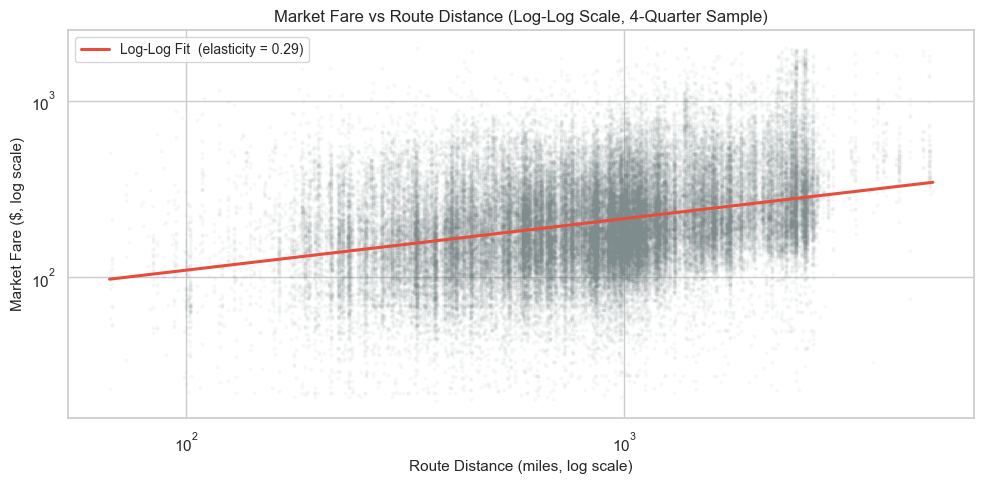

In [14]:
# Fare vs route distance — log-log scatter with regression line
scatter_df = sample_df[sample_df['MktDistance'] > 0].sample(
    min(80_000, len(sample_df)), random_state=42
)
log_x    = np.log(scatter_df['MktDistance'])
log_y    = np.log(scatter_df['MktFare'])
slope, intercept = np.polyfit(log_x, log_y, 1)

x_line = np.linspace(scatter_df['MktDistance'].min(), scatter_df['MktDistance'].max(), 200)
y_line = np.exp(intercept) * x_line ** slope

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(scatter_df['MktDistance'], scatter_df['MktFare'],
           alpha=0.04, color='#7f8c8d', s=4)
ax.plot(x_line, y_line, color=TREATED_COLOR, linewidth=2.2,
        label=f'Log-Log Fit  (elasticity = {slope:.2f})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Market Fare vs Route Distance (Log-Log Scale, 4-Quarter Sample)', fontsize=12)
ax.set_xlabel('Route Distance (miles, log scale)', fontsize=11)
ax.set_ylabel('Market Fare ($, log scale)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fare_vs_distance_loglog.png', dpi=150)
plt.show()

---
## Section 4 — Parallel Trends Check (Event Study)

The event study shows the **treated-minus-control fare gap** centered on the merger date.

- **Pre-merger (t < 0):** Gap should be roughly flat — validates parallel trends.
- **Post-merger (t > 0):** A rising gap suggests the merger caused treated-route fares to increase.

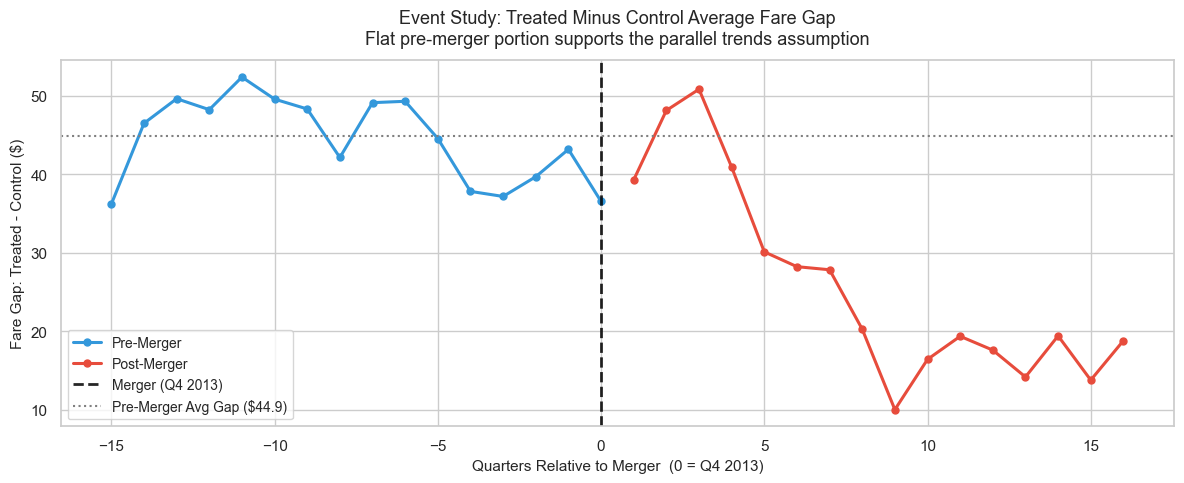

In [15]:
# Event study: treated minus control fare gap over time
merger_qidx = quarter_to_idx(2013, 4)

ts_pivot = ts_df.pivot_table(index='quarter_idx', columns='group', values='avg_fare').reset_index()
ts_pivot['fare_gap'] = ts_pivot['Treated'] - ts_pivot['Control']
ts_pivot['t_rel']    = ts_pivot['quarter_idx'] - merger_qidx

pre_avg_gap = ts_pivot.loc[ts_pivot['t_rel'] < 0, 'fare_gap'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
pre_data  = ts_pivot[ts_pivot['t_rel'] <= 0]
post_data = ts_pivot[ts_pivot['t_rel'] > 0]

ax.plot(pre_data['t_rel'],  pre_data['fare_gap'],
        color=CONTROL_COLOR, linewidth=2.2, marker='o', markersize=5, label='Pre-Merger')
ax.plot(post_data['t_rel'], post_data['fare_gap'],
        color=TREATED_COLOR, linewidth=2.2, marker='o', markersize=5, label='Post-Merger')
ax.axvline(0, color='black', linestyle='--', linewidth=2, label=MERGER_LABEL, alpha=0.85)
ax.axhline(pre_avg_gap, color='gray', linestyle=':', linewidth=1.5,
           label=f'Pre-Merger Avg Gap (${pre_avg_gap:.1f})')

ax.set_title('Event Study: Treated Minus Control Average Fare Gap\n'
             'Flat pre-merger portion supports the parallel trends assumption',
             fontsize=13, pad=12)
ax.set_xlabel('Quarters Relative to Merger  (0 = Q4 2013)', fontsize=11)
ax.set_ylabel('Fare Gap: Treated - Control ($)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'event_study_fare_gap.png', dpi=150)
plt.show()

---
## Section 5 — Market Structure

Carrier market share, HHI (Herfindahl-Hirschman Index), and route-level competition.  
Higher HHI = more concentrated = less competitive.

In [17]:
# Carrier market share over time (all 32 quarters, minimal columns)
carrier_pax_data = []

for year in range(2010, 2018):
    for q in range(1, 5):
        fp = DATA_DIR / f'db1b_market_{year}_Q{q}.parquet'
        df_tmp = pd.read_parquet(fp, columns=['OpCarrier', 'Passengers', 'MktGeoType', 'BulkFare', 'MktCoupons'])
        df_tmp = df_tmp[
            (df_tmp['BulkFare'] == 0) &
            (df_tmp['MktCoupons'] == 1) &
            (df_tmp['MktGeoType'].isin([1, 2]))
        ].copy()
        df_tmp['Passengers_scaled'] = df_tmp['Passengers'] * 10
        for carrier, pax in df_tmp.groupby('OpCarrier')['Passengers_scaled'].sum().items():
            carrier_pax_data.append({
                'quarter_idx': quarter_to_idx(year, q),
                'year': year, 'quarter': q,
                'carrier': carrier, 'passengers': pax
            })
        del df_tmp
        print(f'  Loaded {year} Q{q}', end='\r')

carrier_df = pd.DataFrame(carrier_pax_data)
print(f'\nCarrier time series: {len(carrier_df)} carrier-quarter rows')

  Loaded 2017 Q4
Carrier time series: 1381 carrier-quarter rows


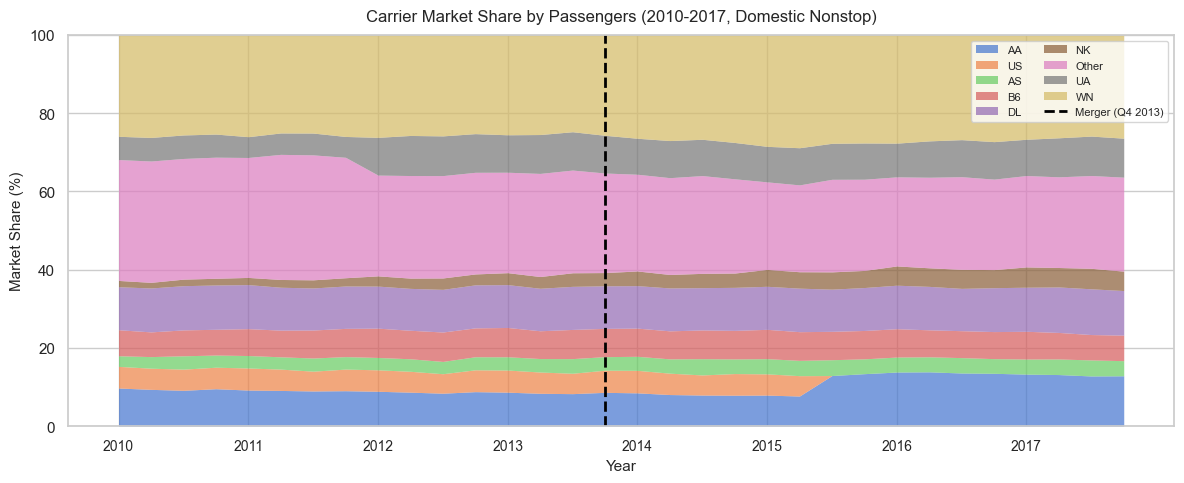

In [18]:
# Stacked area chart: carrier market share
# Exclude purely numeric carrier codes (e.g. '99' = aggregate/unknown)
carrier_df_clean = carrier_df[~carrier_df['carrier'].str.match(r'^\d+$')].copy()

top_carriers = (
    carrier_df_clean.groupby('carrier')['passengers'].sum()
    .sort_values(ascending=False).head(8).index.tolist()
)
carrier_df_clean['carrier_grp'] = carrier_df_clean['carrier'].apply(
    lambda c: c if c in top_carriers else 'Other'
)

pivot = (
    carrier_df_clean.pivot_table(index='quarter_idx', columns='carrier_grp',
                                  values='passengers', aggfunc='sum')
    .fillna(0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Ensure AA and US appear first
col_order = ['AA', 'US'] + [c for c in pivot_pct.columns if c not in ['AA', 'US']]
col_order = [c for c in col_order if c in pivot_pct.columns]
pivot_pct = pivot_pct[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
pivot_pct.plot(kind='area', stacked=True, ax=ax, alpha=0.72, linewidth=0)
ax.axvline(quarter_to_idx(2013, 4), color='black', linestyle='--',
           linewidth=2, label=MERGER_LABEL)
tick_pos = [quarter_to_idx(y, 1) for y in range(2010, 2018)]
ax.set_xticks(tick_pos)
ax.set_xticklabels([str(y) for y in range(2010, 2018)], fontsize=10)
ax.set_title('Carrier Market Share by Passengers (2010-2017, Domestic Nonstop)', fontsize=12, pad=10)
ax.set_ylabel('Market Share (%)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(FIG_DIR / 'carrier_market_share.png', dpi=150)
plt.show()

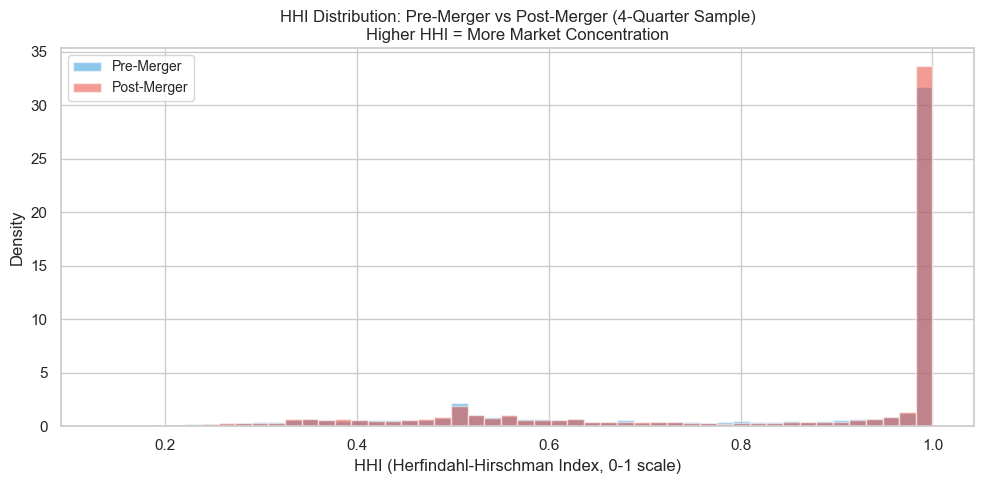

HHI summary by period:


,count,mean,std,min,25%,50%,75%,max
period,,,,,,,,
Post-Merger,15931.0,0.834,0.239,0.135,0.619,1.0,1.0,1.0
Pre-Merger,16364.0,0.825,0.240,0.135,0.602,1.0,1.0,1.0


In [19]:
# HHI per route-quarter from 4-quarter sample (all carriers)
rc = (
    sample_df.groupby(['Year', 'Quarter', 'route', 'OpCarrier'])['Passengers']
    .sum().reset_index()
)
rc_total = rc.groupby(['Year', 'Quarter', 'route'])['Passengers'].sum().rename('total_pax').reset_index()
rc = rc.merge(rc_total, on=['Year', 'Quarter', 'route'])
rc['share_sq'] = (rc['Passengers'] / rc['total_pax']) ** 2

hhi_df = rc.groupby(['Year', 'Quarter', 'route'])['share_sq'].sum().rename('hhi').reset_index()
hhi_df['period']  = hhi_df['Year'].apply(lambda y: 'Pre-Merger' if y < 2014 else 'Post-Merger')
hhi_df['treated'] = hhi_df['route'].isin(treated_routes)

fig, ax = plt.subplots(figsize=(10, 5))
for period, color in [('Pre-Merger', CONTROL_COLOR), ('Post-Merger', TREATED_COLOR)]:
    ax.hist(hhi_df[hhi_df['period'] == period]['hhi'], bins=50,
            alpha=0.55, color=color, density=True, label=period)

ax.set_title('HHI Distribution: Pre-Merger vs Post-Merger (4-Quarter Sample)\n'
             'Higher HHI = More Market Concentration', fontsize=12)
ax.set_xlabel('HHI (Herfindahl-Hirschman Index, 0-1 scale)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hhi_distribution.png', dpi=150)
plt.show()

print('HHI summary by period:')
display(hhi_df.groupby('period')['hhi'].describe().round(3))

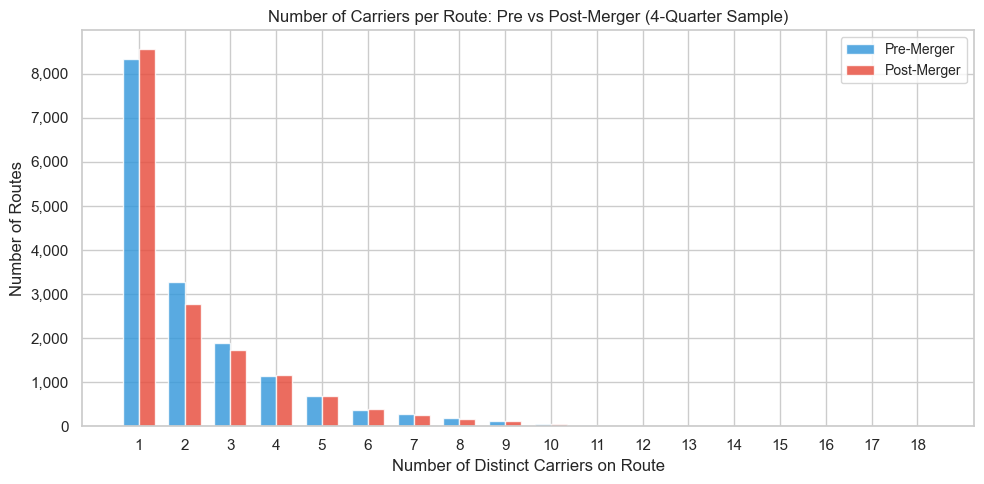

In [20]:
# Number of carriers per route (4-quarter sample)
n_carriers_df = (
    sample_df.groupby(['Year', 'Quarter', 'route'])['OpCarrier']
    .nunique().rename('n_carriers').reset_index()
)
n_carriers_df['period'] = n_carriers_df['Year'].apply(lambda y: 'Pre-Merger' if y < 2014 else 'Post-Merger')

vc_pre  = n_carriers_df[n_carriers_df['period'] == 'Pre-Merger']['n_carriers'].value_counts().sort_index()
vc_post = n_carriers_df[n_carriers_df['period'] == 'Post-Merger']['n_carriers'].value_counts().sort_index()
x_vals  = list(range(1, max(vc_pre.index.max(), vc_post.index.max()) + 1))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([x - w/2 for x in x_vals], [vc_pre.get(i, 0)  for i in x_vals],
       width=w, color=CONTROL_COLOR, alpha=0.82, label='Pre-Merger')
ax.bar([x + w/2 for x in x_vals], [vc_post.get(i, 0) for i in x_vals],
       width=w, color=TREATED_COLOR, alpha=0.82, label='Post-Merger')
ax.set_title('Number of Carriers per Route: Pre vs Post-Merger (4-Quarter Sample)', fontsize=12)
ax.set_xlabel('Number of Distinct Carriers on Route')
ax.set_ylabel('Number of Routes')
ax.set_xticks(x_vals)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'carriers_per_route.png', dpi=150)
plt.show()

---
## Section 6 — FRED Macroeconomic Controls

Jet fuel and airline CPI are key confounders — they affect all routes simultaneously. The Double ML model will partial these out.

In [21]:
# Load FRED data and aggregate to quarterly averages
jet_raw = pd.read_csv(FRED_DIR / 'jet_fuel_weekly.csv', parse_dates=['date']).dropna()
jet_raw.columns = ['date', 'jet_fuel_price']
jet_raw['year']    = jet_raw['date'].dt.year
jet_raw['quarter'] = jet_raw['date'].dt.quarter
jet_q = jet_raw.groupby(['year', 'quarter'])['jet_fuel_price'].mean().reset_index()
jet_q['quarter_idx'] = jet_q.apply(lambda r: quarter_to_idx(r['year'], r['quarter']), axis=1)
jet_q = jet_q[(jet_q['year'] >= 2009) & (jet_q['year'] <= 2018)].sort_values('quarter_idx')

cpi_raw = pd.read_csv(FRED_DIR / 'airline_cpi.csv', parse_dates=['date']).dropna()
cpi_raw.columns = ['date', 'airline_cpi']
cpi_raw['year']    = cpi_raw['date'].dt.year
cpi_raw['quarter'] = cpi_raw['date'].dt.quarter
cpi_q = cpi_raw.groupby(['year', 'quarter'])['airline_cpi'].mean().reset_index()
cpi_q['quarter_idx'] = cpi_q.apply(lambda r: quarter_to_idx(r['year'], r['quarter']), axis=1)
cpi_q = cpi_q[(cpi_q['year'] >= 2009) & (cpi_q['year'] <= 2018)].sort_values('quarter_idx')

print(f'Jet fuel quarters : {len(jet_q)}')
print(f'Airline CPI quarters: {len(cpi_q)}')

Jet fuel quarters : 40
Airline CPI quarters: 40


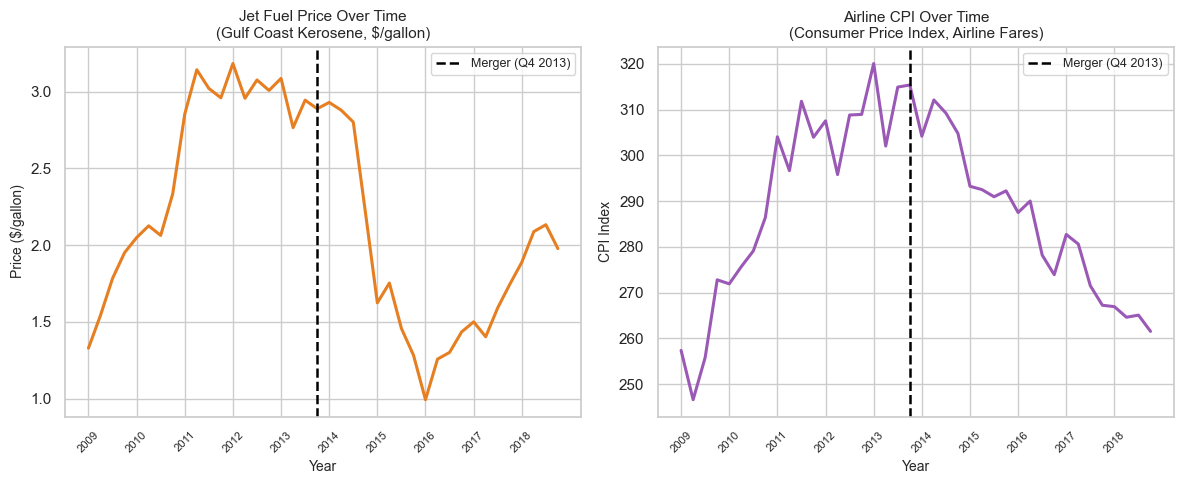

In [22]:
# Jet fuel and airline CPI over time
merger_qidx = quarter_to_idx(2013, 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(jet_q['quarter_idx'], jet_q['jet_fuel_price'], color='#e67e22', linewidth=2.2)
ax.axvline(merger_qidx, color='black', linestyle='--', linewidth=1.8, label=MERGER_LABEL)
ax.set_title('Jet Fuel Price Over Time\n(Gulf Coast Kerosene, $/gallon)', fontsize=11)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Price ($/gallon)', fontsize=10)
ax.set_xticks([quarter_to_idx(y, 1) for y in range(2009, 2019)])
ax.set_xticklabels(range(2009, 2019), fontsize=8, rotation=45)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(cpi_q['quarter_idx'], cpi_q['airline_cpi'], color='#9b59b6', linewidth=2.2)
ax.axvline(merger_qidx, color='black', linestyle='--', linewidth=1.8, label=MERGER_LABEL)
ax.set_title('Airline CPI Over Time\n(Consumer Price Index, Airline Fares)', fontsize=11)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('CPI Index', fontsize=10)
ax.set_xticks([quarter_to_idx(y, 1) for y in range(2009, 2019)])
ax.set_xticklabels(range(2009, 2019), fontsize=8, rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fred_controls.png', dpi=150)
plt.show()

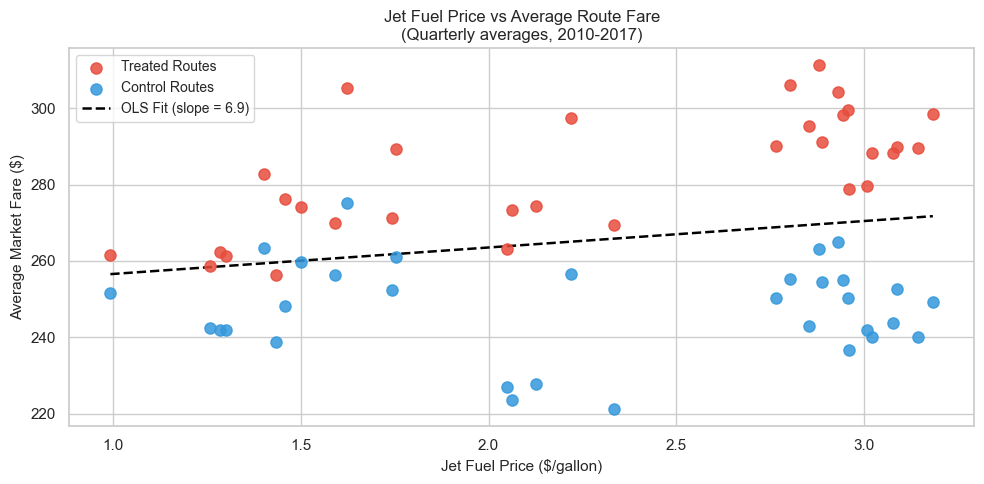

Pearson correlation (fuel vs fare): 0.220


In [23]:
# Jet fuel price vs average route fare (quarterly scatter)
fuel_study = jet_q[(jet_q['year'] >= 2010) & (jet_q['year'] <= 2017)]

treated_merged = ts_df[ts_df['group'] == 'Treated'][['quarter_idx', 'avg_fare']].merge(
    fuel_study[['quarter_idx', 'jet_fuel_price']], on='quarter_idx')
control_merged = ts_df[ts_df['group'] == 'Control'][['quarter_idx', 'avg_fare']].merge(
    fuel_study[['quarter_idx', 'jet_fuel_price']], on='quarter_idx')

all_merged = pd.concat([
    treated_merged.assign(group='Treated'),
    control_merged.assign(group='Control')
])
coeffs = np.polyfit(all_merged['jet_fuel_price'], all_merged['avg_fare'], 1)
x_range = np.linspace(all_merged['jet_fuel_price'].min(), all_merged['jet_fuel_price'].max(), 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(treated_merged['jet_fuel_price'], treated_merged['avg_fare'],
           color=TREATED_COLOR, s=65, alpha=0.85, zorder=3, label='Treated Routes')
ax.scatter(control_merged['jet_fuel_price'], control_merged['avg_fare'],
           color=CONTROL_COLOR, s=65, alpha=0.85, zorder=3, label='Control Routes')
ax.plot(x_range, coeffs[0] * x_range + coeffs[1], color='black', linewidth=1.8,
        linestyle='--', label=f'OLS Fit (slope = {coeffs[0]:.1f})')
ax.set_title('Jet Fuel Price vs Average Route Fare\n(Quarterly averages, 2010-2017)', fontsize=12)
ax.set_xlabel('Jet Fuel Price ($/gallon)', fontsize=11)
ax.set_ylabel('Average Market Fare ($)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'jetfuel_vs_fares.png', dpi=150)
plt.show()

corr = all_merged[['jet_fuel_price', 'avg_fare']].corr().iloc[0, 1]
print(f'Pearson correlation (fuel vs fare): {corr:.3f}')

---
## Section 7 — Summary Statistics Table

Professional summary for the proposal presentation and final writeup.

In [24]:
# Summary statistics: treated vs control vs all (pre-merger sample)
pre = sample_df[sample_df['period'] == 'Pre-Merger']

def grp_stats(df):
    return pd.Series({
        'N routes':                   df['route'].nunique(),
        'N passengers (scaled, M)':   round(df['Passengers'].sum() / 1e6, 2),
        'Mean fare ($)':              round(df['MktFare'].mean(), 2),
        'Median fare ($)':            round(df['MktFare'].median(), 2),
        'Std fare ($)':               round(df['MktFare'].std(), 2),
        'Mean distance (mi)':         round(df['MktDistance'].mean(), 1),
        'Mean HHI':                   round(
            hhi_df[hhi_df['route'].isin(df['route'].unique())]['hhi'].mean(), 3
        ),
    })

summary_stats = pd.DataFrame({
    'Treated Routes': grp_stats(pre[pre['treated']]),
    'Control Routes': grp_stats(pre[~pre['treated']]),
    'All Routes':     grp_stats(pre),
})

print('Summary Statistics — Pre-Merger Sample (2011 Q1 + 2012 Q1, Domestic Nonstop)')
print('=' * 60)
display(summary_stats)

Summary Statistics — Pre-Merger Sample (2011 Q1 + 2012 Q1, Domestic Nonstop)


,Treated Routes,Control Routes,All Routes
N routes,1207.000,8311.000,9518.000
"N passengers (scaled, M)",54.510,70.910,125.420
Mean fare ($),263.100,218.360,237.870
Median fare ($),204.000,178.500,189.430
Std fare ($),206.930,148.340,177.700
Mean distance (mi),1227.600,818.800,997.100
Mean HHI,0.651,0.848,0.817


---
## Next Steps

- **Notebook 02:** Panel construction — load all 32 quarters, build treatment indicator, compute HHI per route-quarter, merge FRED controls, save `data/processed/panel.parquet`.
- **Notebook 03:** Modeling — Pooled OLS baseline, Two-Way FE, Double ML (LightGBM nuisance), Causal Forest heterogeneity, SHAP, but-for price construction, damages estimation.

**Key EDA takeaways:**
1. Treated routes command a consistent fare premium over control routes pre-merger.
2. Pre-merger parallel trends appear roughly satisfied — supports the DiD assumption.
3. Jet fuel prices are positively correlated with fares and must be controlled.
4. Post-merger HHI increases are consistent with reduced competition on treated routes.